In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Trasformazioni: resize a 64x64 e normalizzazione in [0,1]
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()  # ToTensor già porta i valori in [0,1]
])

train_dataset = datasets.Flowers102(
    root="./data",
    split="train",
    transform=transform,
    download=True
)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)

print("Numero immagini:", len(train_dataset))

# Verifica visiva di un batch
images, _ = next(iter(train_loader))
print("Shape batch:", images.shape)  # atteso: [batch_size, 3, 64, 64]

Device: cuda
Numero immagini: 1020
Shape batch: torch.Size([64, 3, 64, 64])


In [7]:
class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        # --- ENCODER ---
        self.enc_conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),   # 64x64 -> 32x32
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # 32x32 -> 16x16
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # 16x16 -> 8x8
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),# 8x8 -> 4x4
            nn.ReLU(),
        )
        self.flatten_dim = 256 * 4 * 4

        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)

        # --- DECODER ---
        self.decoder_input = nn.Linear(latent_dim, self.flatten_dim)

        self.dec_conv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1), # 4x4 -> 8x8
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 8x8 -> 16x16
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),   # 16x16 -> 32x32
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),    # 32x32 -> 64x64
            nn.Sigmoid()  # output in [0,1]
        )

    def encode(self, x):
        h = self.enc_conv(x)
        h = h.view(h.size(0), -1)  # flatten
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + std * eps
        return z

    def decode(self, z):
        h = self.decoder_input(z)
        h = h.view(h.size(0), 256, 4, 4)  # reshape per le conv transpose
        x_recon = self.dec_conv(h)
        return x_recon

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar


model = VAE(latent_dim=128).to(device)
print(model)

VAE(
  (enc_conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): ReLU()
  )
  (fc_mu): Linear(in_features=4096, out_features=128, bias=True)
  (fc_logvar): Linear(in_features=4096, out_features=128, bias=True)
  (decoder_input): Linear(in_features=128, out_features=4096, bias=True)
  (dec_conv): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): ConvTranspose2d(32, 3, kernel_size=(4, 4), stride=(2, 

In [8]:
def vae_loss(x_recon, x, mu, logvar):
    # 1. Reconstruction Loss (BCE, sommata sui pixel, poi mediata sul batch)
    recon_loss = nn.functional.binary_cross_entropy(
        x_recon, x, reduction='sum'
    ) / x.size(0)

    # 2. KL Divergence: KL(N(mu, sigma^2) || N(0, 1))
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    kl_div = kl_div / x.size(0)

    return recon_loss, kl_div

In [9]:
def train_vae(model, train_loader, epochs=30, lr=1e-3, kl_anneal_epochs=10):
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'recon_loss': [], 'kl_loss': [], 'beta': []}

    for epoch in range(epochs):
        model.train()
        epoch_recon = 0.0
        epoch_kl = 0.0

        # Beta cresce linearmente da 0 a 1 durante kl_anneal_epochs, poi resta a 1
        beta = min(1.0, epoch / kl_anneal_epochs)

        for batch_idx, (x, _) in enumerate(train_loader):
            x = x.to(device)

            optimizer.zero_grad()
            x_recon, mu, logvar = model(x)
            recon_loss, kl_loss = vae_loss(x_recon, x, mu, logvar)

            loss = recon_loss + beta * kl_loss
            loss.backward()
            optimizer.step()

            epoch_recon += recon_loss.item()
            epoch_kl += kl_loss.item()

        avg_recon = epoch_recon / len(train_loader)
        avg_kl = epoch_kl / len(train_loader)

        history['recon_loss'].append(avg_recon)
        history['kl_loss'].append(avg_kl)
        history['beta'].append(beta)

        print(f"Epoch {epoch+1}/{epochs} | Recon: {avg_recon:.2f} | KL: {avg_kl:.2f} | Beta: {beta:.2f}")

    return history


history = train_vae(model, train_loader, epochs=30, kl_anneal_epochs=10)

Epoch 1/30 | Recon: 8301.34 | KL: 13.20 | Beta: 0.00
Epoch 2/30 | Recon: 7822.12 | KL: 77.54 | Beta: 0.10
Epoch 3/30 | Recon: 7641.75 | KL: 96.25 | Beta: 0.20
Epoch 4/30 | Recon: 7483.83 | KL: 70.27 | Beta: 0.30
Epoch 5/30 | Recon: 7337.97 | KL: 64.57 | Beta: 0.40
Epoch 6/30 | Recon: 7272.77 | KL: 65.15 | Beta: 0.50
Epoch 7/30 | Recon: 7229.16 | KL: 62.92 | Beta: 0.60
Epoch 8/30 | Recon: 7141.00 | KL: 67.58 | Beta: 0.70
Epoch 9/30 | Recon: 7089.14 | KL: 67.83 | Beta: 0.80
Epoch 10/30 | Recon: 7017.16 | KL: 74.24 | Beta: 0.90
Epoch 11/30 | Recon: 6986.72 | KL: 71.41 | Beta: 1.00
Epoch 12/30 | Recon: 6959.92 | KL: 69.68 | Beta: 1.00
Epoch 13/30 | Recon: 6932.92 | KL: 72.66 | Beta: 1.00
Epoch 14/30 | Recon: 6913.15 | KL: 73.91 | Beta: 1.00
Epoch 15/30 | Recon: 6898.71 | KL: 74.71 | Beta: 1.00
Epoch 16/30 | Recon: 6894.00 | KL: 75.62 | Beta: 1.00
Epoch 17/30 | Recon: 6875.06 | KL: 74.37 | Beta: 1.00
Epoch 18/30 | Recon: 6852.24 | KL: 76.86 | Beta: 1.00
Epoch 19/30 | Recon: 6837.65 | KL: 76

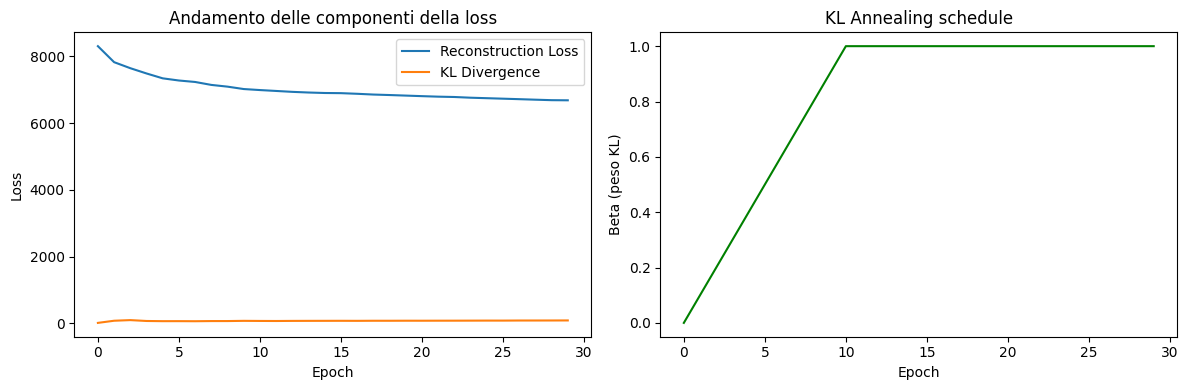

In [10]:
# Plot delle due componenti della loss
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['recon_loss'], label='Reconstruction Loss')
axes[0].plot(history['kl_loss'], label='KL Divergence')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].set_title('Andamento delle componenti della loss')

axes[1].plot(history['beta'], color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Beta (peso KL)')
axes[1].set_title('KL Annealing schedule')

plt.tight_layout()
plt.show()